In [1]:
import pandas as pd
import re
import jieba.posseg as psg
import numpy as np

reviews = '../data/reviews.csv'   # 数据文件
# 读取数据
df = pd.read_csv(reviews)

print(df.shape)

(2000, 5)


In [2]:
df.tail(8)#查看后8个数据

,content,creationTime,nickname,referenceName,content_type
1992,新买的热水器 降温按钮没用，京东厂家来回打电话，一会换显示板 一会换机器，又要拆又要等，算了...,2016-11-26 18:23:13,j***1,美的（Midea）60升预约洗浴 无线遥控 电热水器 F60-15WB5(Y),neg
1993,之前客服说里面带安装材料，什么都没有，一边高一边低,2016-11-25 23:05:40,j***h,美的（Midea）60升预约洗浴 无线遥控 电热水器 F60-15WB5(Y),neg
1994,为什么不给用不锈钢软管啊，，差评,2016-11-25 16:27:46,X***7,美的（Midea）60升预约洗浴 无线遥控 电热水器 F60-15WB5(Y),neg
1995,差评，差的一塌糊涂，千万别买，上当了，,2016-11-25 14:57:52,沫沫19900404,美的（Midea）60升预约洗浴 无线遥控 电热水器 F60-15WB5(Y),neg
1996,热水器还没有安装，就搞一肚子气，安装人员今天推明天，明天推后天，售后安装服务太差，给差评，目...,2016-11-25 13:39:28,j***l,美的（Midea）60升预约洗浴 无线遥控 电热水器 F60-15WB5(Y),neg
1997,好不容易网购一下还漏电,2016-11-25 13:38:49,K***T,美的（Midea）60升预约洗浴 无线遥控 电热水器 F60-15WB5(Y),neg
1998,东西送的挺快，后期报装2天还没人联系我，售后太差,2016-11-25 10:19:20,j***p,美的（Midea）60升预约洗浴 无线遥控 电热水器 F60-15WB5(Y),neg
1999,买了两个，送到一个，还有一个至今未送到。,2016-11-25 10:17:45,s***8,美的（Midea）60升预约洗浴 无线遥控 电热水器 F60-15WB5(Y),neg


In [3]:
content = df.drop_duplicates(subset=['content']) 
print(content.shape)

(1973, 5)


In [4]:
# 定义要去除的字符模式
strinfo = re.compile(r'[a-zA-Z0-9]')  # 匹配所有英文和数字

# 应用数据清洗
content['cleaned_content'] = content['content'].apply(lambda x: strinfo.sub('', str(x)))

print(f"数据清洗后数据个数：{content.shape}")

数据清洗后数据个数：(1973, 6)


C:\Users\yuhexue\AppData\Local\Temp\ipykernel_16732\777440030.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  content['cleaned_content'] = content['content'].apply(lambda x: strinfo.sub('', str(x)))


In [5]:
# 分词
# 自定义简单分词函数
def worker(text):
    """
    分词函数，进行中文分词和词性标注
    """
    if pd.isna(text) or text == '':
        return []
    
    # 使用jieba进行分词和词性标注
    words = psg.cut(str(text))
    # 返回(词语, 词性)的列表
    result = []
    for word, flag in words:
        result.append((word, flag))
    return result

# 应用分词
seg_word = content['cleaned_content'].apply(worker)
seg_word

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\yuhexue\AppData\Local\Temp\jieba.cache
Loading model cost 1.174 seconds.
Prefix dict has been built successfully.


0       [(东西, ns), (收到, v), (这么久, r), (，, x), (都, d), ...
1       [(安装, v), (师傅, nr), (很, d), (给, p), (力, n), (，...
2       [(还, d), (没, v), (安装, v), (，, x), (基本, n), (满意...
3       [(电热水器, n), (收到, v), (了, ul), (，, x), (京东, ns)...
4       [(用, p), (了, ul), (几次, m), (才, d), (来, v), (评价...
                              ...                        
1995    [(差, a), (评, n), (，, x), (差, a), (的, uj), (一塌糊...
1996    [(热水器, n), (还, d), (没有, v), (安装, v), (，, x), (...
1997      [(好不容易, l), (网购, n), (一下, m), (还, d), (漏电, nz)]
1998    [(东西, ns), (送, v), (的, uj), (挺快, v), (，, x), (...
1999    [(买, v), (了, ul), (两个, m), (，, x), (送到, v), (一...
Name: cleaned_content, Length: 1973, dtype: object

In [6]:
# 将词语转为数据框形式，一列是词，一列是词语所在的句子ID，最后一列是词语在该句子的位置
# 计算每一评论中词的个数
n_word = seg_word.apply(len)  # 每一评论中词的个数
n_word

0       33
1       13
2        6
3       43
4       45
        ..
1995    13
1996    37
1997     5
1998    16
1999    13
Name: cleaned_content, Length: 1973, dtype: int64

In [7]:
n_content = content.index.tolist()  # 获取评论的索引列表
index_content = []                  # 将嵌套的列表展开，作为词所在评论的id

# 遍历每个评论，根据词语数量重复评论ID
for i, seg_list in enumerate(seg_word):
    n = len(seg_list)  # 当前评论的词语数量
    index_content.extend([n_content[i]] * n)  # 将评论ID重复n次

index_content  # 查看处理结果

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,
 8,


In [8]:
seg_word = content['cleaned_content'].apply(worker)  # 分词结果，包含词语和词性
word = []                     # 分词-只提取词语

# 从seg_word中提取所有词语（不包含词性）
for seg_list in seg_word:
    if seg_list:  # 确保不是空列表
        # 提取每个(词语, 词性)元组中的词语部分
        words_only = [item[0] for item in seg_list]
        word.extend(words_only)

word  # 查看处理结果

['东西',
 '收到',
 '这么久',
 '，',
 '都',
 '忘',
 '了',
 '去',
 '好评',
 '，',
 '美的',
 '大',
 '品牌',
 '，',
 '值得',
 '信赖',
 '，',
 '东西',
 '整体',
 '来看',
 '，',
 '个人感觉',
 '还',
 '不错',
 '，',
 '没有',
 '出现',
 '什么',
 '问题',
 '，',
 '值得',
 '拥有',
 '！',
 '安装',
 '师傅',
 '很',
 '给',
 '力',
 '，',
 '热水器',
 '也好',
 '用',
 '，',
 '感谢',
 '美的',
 '。',
 '还',
 '没',
 '安装',
 '，',
 '基本',
 '满意',
 '电热水器',
 '收到',
 '了',
 '，',
 '京东',
 '自营',
 '商品',
 '就是',
 '好',
 '，',
 '发货',
 '速度',
 '快',
 '，',
 '品质',
 '有',
 '保障',
 '，',
 '安装',
 '效果',
 '好',
 '，',
 '宝贝',
 '非常',
 '喜欢',
 '，',
 '冬天',
 '可以',
 '小时',
 '有',
 '热水',
 '了',
 '，',
 '京东',
 '自营',
 '值得',
 '信赖',
 '，',
 '值得',
 '推荐',
 '京东',
 '自营',
 '。',
 '用',
 '了',
 '几次',
 '才',
 '来',
 '评价',
 '，',
 '对',
 '产品',
 '非常',
 '满意',
 '，',
 '加热',
 '快',
 '保温',
 '时间',
 '长',
 '，',
 '售后服务',
 '特别',
 '好',
 '，',
 '主动',
 '打电话',
 '询问',
 '送货',
 '情况',
 '帮',
 '我',
 '联系',
 '安装',
 '，',
 '非常感谢',
 '售后',
 '大姐',
 '的',
 '服务',
 '！',
 '下次',
 '购买',
 '还',
 '会',
 '考虑',
 '美的',
 '！',
 '物美价廉',
 '啊',
 '，',
 '特别',
 '划算',
 '的',
 '，',
 '而且',
 '加热',
 '速度',
 

In [9]:
nature = []                    # 分词对应的词性

# 从seg_word中提取所有词性
for seg_list in seg_word:
    if seg_list:  # 确保不是空列表
        # 提取每个(词语, 词性)元组中的词性部分
        pos_only = [item[1] for item in seg_list]
        nature.extend(pos_only)

nature  # 查看处理后的数据

['ns',
 'v',
 'r',
 'x',
 'd',
 'v',
 'ul',
 'v',
 'v',
 'x',
 'nr',
 'a',
 'n',
 'x',
 'v',
 'n',
 'x',
 'ns',
 'n',
 'u',
 'x',
 'n',
 'd',
 'a',
 'x',
 'v',
 'v',
 'r',
 'n',
 'x',
 'v',
 'v',
 'x',
 'v',
 'nr',
 'd',
 'p',
 'n',
 'x',
 'n',
 'y',
 'p',
 'x',
 'v',
 'nr',
 'x',
 'd',
 'v',
 'v',
 'x',
 'n',
 'v',
 'n',
 'v',
 'ul',
 'x',
 'ns',
 'vn',
 'n',
 'd',
 'a',
 'x',
 'n',
 'n',
 'a',
 'x',
 'n',
 'v',
 'v',
 'x',
 'v',
 'n',
 'a',
 'x',
 'nr',
 'd',
 'v',
 'x',
 't',
 'c',
 'n',
 'v',
 'n',
 'ul',
 'x',
 'ns',
 'vn',
 'v',
 'n',
 'x',
 'v',
 'v',
 'ns',
 'vn',
 'x',
 'p',
 'ul',
 'm',
 'd',
 'v',
 'n',
 'x',
 'p',
 'n',
 'd',
 'v',
 'x',
 'v',
 'a',
 'n',
 'n',
 'a',
 'x',
 'l',
 'd',
 'a',
 'x',
 'b',
 'l',
 'v',
 'v',
 'n',
 'v',
 'r',
 'n',
 'v',
 'x',
 'i',
 'n',
 'n',
 'uj',
 'vn',
 'x',
 't',
 'v',
 'd',
 'v',
 'v',
 'nr',
 'x',
 'l',
 'zg',
 'x',
 'd',
 'v',
 'uj',
 'x',
 'c',
 'v',
 'n',
 'a',
 'x',
 's',
 'p',
 'uz',
 'a',
 'd',
 'a',
 'n',
 'x',
 'v',
 'd',
 'a',


In [10]:
content_type = []  # 评论类型（正面评价，负面评价）

# 根据每个评论的词语数量，重复对应的评论类型
for i, seg_list in enumerate(seg_word):
    n = len(seg_list)  # 当前评论的词语数量
    # 获取该评论的content_type，并重复n次
    comment_type = df['content_type'].iloc[i]
    content_type.extend([comment_type] * n)

content_type  # 查看处理后的数据

['pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',
 'pos',


In [11]:
# 查看处理后的数据结果
result = pd.DataFrame({
    'index_content': index_content,
    'word': word,
    'nature': nature,
    'content_type': content_type
})

result  

,index_content,word,nature,content_type
0,0,东西,ns,pos
1,0,收到,v,pos
2,0,这么久,r,pos
3,0,，,x,pos
4,0,都,d,pos
...,...,...,...,...
65270,1999,一个,m,neg
65271,1999,至今,d,neg
65272,1999,未,d,neg
65273,1999,送到,v,neg


In [12]:
# 删除标点符号
result = result[result['nature'] != 'x']  # x表示标点符号

result  # 查看处理后的数据

,index_content,word,nature,content_type
0,0,东西,ns,pos
1,0,收到,v,pos
2,0,这么久,r,pos
4,0,都,d,pos
5,0,忘,v,pos
...,...,...,...,...
65269,1999,还有,v,neg
65270,1999,一个,m,neg
65271,1999,至今,d,neg
65272,1999,未,d,neg


In [13]:
# 删除停用词
stop_path = open("../data/stoplist.txt", 'r', encoding='UTF-8')
stop = stop_path.read()  # 读取停用词文件
stop = stop.splitlines()  # 按行分割为列表
word = result['word']  # 获取词语列
result = result[~result['word'].isin(stop)]  # 删除停用词

result  # 查看处理后的数据

,index_content,word,nature,content_type
0,0,东西,ns,pos
1,0,收到,v,pos
2,0,这么久,r,pos
5,0,忘,v,pos
8,0,好评,v,pos
...,...,...,...,...
65261,1998,差,a,neg
65264,1999,两个,m,neg
65266,1999,送到,v,neg
65272,1999,未,d,neg


In [14]:
# 构造各词在对应评论的位置列
n_word = result.groupby('index_content').size()  # 每个评论的词语数量
index_word = []                    # 表示词语在该评论的位置

# 为每个评论生成位置索引
for content_id in result['index_content'].unique():
    word_count = len(result[result['index_content'] == content_id])
    index_word.extend(range(word_count))

index_word  # 查看处理后的数据

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 0,
 1,
 2,
 3,
 4,
 5,
 0,
 1,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 0,
 1,
 2,
 3,
 4,
 0,
 1,
 2,
 3,
 4,
 5,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,


In [15]:
# 合并评论id，评论中词的id，词，词性，评论类型
# 构造各词在对应评论的位置列
n_word = result.groupby('index_content').size()  # 每个评论的词语数量
index_word = []                    # 表示词语在该评论的位置

# 为每个评论生成位置索引
for content_id in result['index_content'].unique():
    word_count = len(result[result['index_content'] == content_id])
    index_word.extend(range(word_count))

# 合并评论id，评论中词的id，词，词性，评论类型
result['index_word'] = index_word  # 使用生成的位置列表作为词语在评论中的ID

result  # 查看处理后的数据

C:\Users\yuhexue\AppData\Local\Temp\ipykernel_16732\1024137628.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['index_word'] = index_word  # 使用生成的位置列表作为词语在评论中的ID


,index_content,word,nature,content_type,index_word
0,0,东西,ns,pos,0
1,0,收到,v,pos,1
2,0,这么久,r,pos,2
5,0,忘,v,pos,3
8,0,好评,v,pos,4
...,...,...,...,...,...
65261,1998,差,a,neg,9
65264,1999,两个,m,neg,0
65266,1999,送到,v,neg,1
65272,1999,未,d,neg,2


In [16]:
# 提取含有名词类的评论
ind = result['nature'].str.contains('^n', na=False)  # 匹配以n开头的词性（名词）
result = result[ind]  # 筛选含有名词的行

result  # 查看处理后的数据

,index_content,word,nature,content_type,index_word
0,0,东西,ns,pos,0
10,0,美的,nr,pos,5
12,0,品牌,n,pos,6
15,0,信赖,n,pos,8
17,0,东西,ns,pos,9
...,...,...,...,...,...
65230,1996,差评,n,neg,16
65242,1997,网购,n,neg,1
65245,1997,漏电,nz,neg,2
65246,1998,东西,ns,neg,0


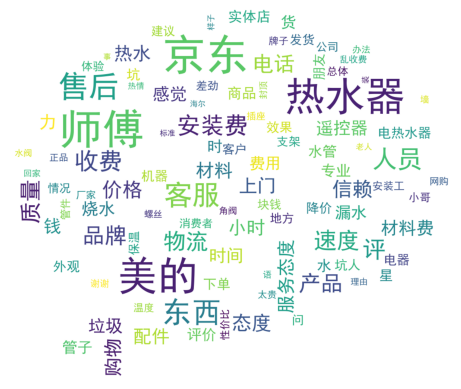

In [17]:
# 代码12-5 绘制词云

import matplotlib.pyplot as plt
from wordcloud import WordCloud

frequencies = result['word'].value_counts()  # 处理分词权重
frequencies = frequencies.sort_values(ascending=False)  # 排序
backgroud_Image = plt.imread('../data/pl.jpg')  # 设置词云图背景用的图
wordcloud = WordCloud(font_path='../data/simhei.ttf',  # 设置字体
                      max_words=100,  # 设置最大显示词格式
                      background_color='white',  # 设置背景色
                      mask=backgroud_Image,  # 设置词云图背景图
                      max_font_size=100,  # 设置字体最大值
                      random_state=42,  # 设置随机种子
                      width=800,  # 设置图片宽度
                      height=600  # 设置图片高度
                     )
my_wordcloud = wordcloud.fit_words(frequencies)  # 填充词云图
plt.imshow(my_wordcloud)  # 显示词云图
plt.axis('off')  # 去除图片的坐标轴
plt.show()

In [18]:
# 将结果写到文件“tmp/word.csv”
result.to_csv("../tmp/word.csv", index = False, encoding = 'utf-8')

In [19]:
#  匹配情感词

import pandas as pd
import numpy as np
word = pd.read_csv("../tmp/word.csv")

# 读入正面、负面情感评价词
def read_word_list(file_path):
    """读取词语列表文件"""
    with open(file_path, 'r', encoding='utf-8') as f:
        words = [line.strip() for line in f if line.strip()]
    return pd.Series(words)

pos_comment = read_word_list("../data/正面评价词语（中文）.txt")
neg_comment = read_word_list("../data/负面评价词语（中文）.txt")
pos_emotion = read_word_list("../data/正面情感词语（中文）.txt")
neg_emotion = read_word_list("../data/负面情感词语（中文）.txt")

In [20]:
# 合并情感词与评价词

def read_sentiment_file_clean(file_path):
    """读取情感词文件并清理BOM头"""
    try:
        with open(file_path, 'r', encoding='utf-8-sig') as f:  # 使用utf-8-sig自动去除BOM
            words = [line.strip() for line in f if line.strip()]
        return words
    except FileNotFoundError:
        print(f"文件 {file_path} 未找到")
        return []

# 读取所有情感词文件
pos_emotion_list = read_sentiment_file_clean("../data/正面情感词语（中文）.txt")
pos_comment_list = read_sentiment_file_clean("../data/正面评价词语（中文）.txt")
neg_emotion_list = read_sentiment_file_clean("../data/负面情感词语（中文）.txt")
neg_comment_list = read_sentiment_file_clean("../data/负面评价词语（中文）.txt")

# 合并并处理
all_positive = list(set(pos_emotion_list + pos_comment_list))
all_negative = list(set(neg_emotion_list + neg_comment_list))

# 移除重复词语
intersection = set(all_positive).intersection(set(all_negative))
all_positive = [word for word in all_positive if word not in intersection]
all_negative = [word for word in all_negative if word not in intersection]

# 创建最终DataFrame
posneg = pd.concat([
    pd.DataFrame({'word': all_positive, 'weight': 1}),
    pd.DataFrame({'word': all_negative, 'weight': -1})
], ignore_index=True)

posneg

,word,weight
0,吉祥如意,1
1,纯洁,1
2,良,1
3,打心眼里,1
4,精心,1
...,...,...
8663,碎,-1
8664,庸碌,-1
8665,狡兔三窟,-1
8666,貌似强大,-1


In [21]:
# 将分词结果与正负面情感词表合并，定位情感词
data_posneg = pd.merge(result, posneg, on='word', how='left')

data_posneg = data_posneg[['word', 'weight', 'index_content', 'nature', 'content_type', 'index_word']]
data_posneg  # 查看处理后的数据

,word,weight,index_content,nature,content_type,index_word
0,东西,NaN,0,ns,pos,0
1,美的,NaN,0,nr,pos,5
2,品牌,NaN,0,n,pos,6
3,信赖,1.0,0,n,pos,8
4,东西,NaN,0,ns,pos,9
...,...,...,...,...,...,...
10935,差评,-1.0,1996,n,neg,16
10936,网购,NaN,1997,n,neg,1
10937,漏电,-1.0,1997,nz,neg,2
10938,东西,NaN,1998,ns,neg,0


In [22]:
# 根据情感词前时候有否定词或双层否定词对情感值进行修正
# 载入否定词表
notdict = pd.read_csv("../data/not.csv")
notdict.head(5) #查看前5个数据

,term
0,不
1,没
2,无
3,非
4,莫


In [23]:
# 处理否定修饰词
data_posneg['amend_weight'] = data_posneg['weight']  # 构造新列，作为经过否定词修正后的情感值
data_posneg['id'] = range(len(data_posneg))  # 构造新列id
only_inclination = data_posneg[data_posneg['amend_weight'].notna()]  # 只保留有情感值的词语
only_inclination.index = range(len(only_inclination))  # 构造索引
index = only_inclination['id']  # 获取情感词的id
only_inclination  # 查看处理后的数据

,word,weight,index_content,nature,content_type,index_word,amend_weight,id
0,信赖,1.0,0,n,pos,8,1.0,3
1,信赖,1.0,3,n,pos,19,1.0,22
2,物美,1.0,6,nz,pos,3,1.0,34
3,中,1.0,8,ns,pos,25,1.0,47
4,中,1.0,8,ns,pos,43,1.0,57
...,...,...,...,...,...,...,...,...
789,热,1.0,1984,n,neg,2,1.0,10885
790,差劲,-1.0,1990,n,neg,3,-1.0,10902
791,板,-1.0,1992,ng,neg,12,-1.0,10920
792,差评,-1.0,1996,n,neg,16,-1.0,10935


In [24]:
for i in np.arange(0, len(only_inclination)):
    review = data_posneg[data_posneg['index_content'] == only_inclination['index_content'].iloc[i]]  # 提取第i个情感词所在的评论
    review.index = range(len(review))  # 重设索引
    affective = only_inclination['index_word'].iloc[i]  # 第i个情感值在该文档的位置
    if affective == 1:
        ne = sum(review.loc[0:0, 'word'].isin(notdict['term']))  # 检查第一个位置是否有否定词
        if ne == 1:
            data_posneg['amend_weight'][index[i]] = -data_posneg['amend_weight'][index[i]]  # 反转情感权重
            
    elif affective > 1:
        ne = sum(review.loc[affective-1:affective, 'word'].isin(notdict['term']))  # 检查前一个位置是否有否定词
        
        if ne == 1:
            data_posneg['amend_weight'][index[i]] = -data_posneg['amend_weight'][index[i]]  # 反转情感权重
            
only_inclination  # 查看处理后的数据

,word,weight,index_content,nature,content_type,index_word,amend_weight,id
0,信赖,1.0,0,n,pos,8,1.0,3
1,信赖,1.0,3,n,pos,19,1.0,22
2,物美,1.0,6,nz,pos,3,1.0,34
3,中,1.0,8,ns,pos,25,1.0,47
4,中,1.0,8,ns,pos,43,1.0,57
...,...,...,...,...,...,...,...,...
789,热,1.0,1984,n,neg,2,1.0,10885
790,差劲,-1.0,1990,n,neg,3,-1.0,10902
791,板,-1.0,1992,ng,neg,12,-1.0,10920
792,差评,-1.0,1996,n,neg,16,-1.0,10935


In [25]:
# 更新只保留情感值的数据
only_inclination = data_posneg[data_posneg['amend_weight'].notna()]  # 删除空值
only_inclination  # 查看处理后的数据

,word,weight,index_content,nature,content_type,index_word,amend_weight,id
3,信赖,1.0,0,n,pos,8,1.0,3
22,信赖,1.0,3,n,pos,19,1.0,22
34,物美,1.0,6,nz,pos,3,1.0,34
47,中,1.0,8,ns,pos,25,1.0,47
57,中,1.0,8,ns,pos,43,1.0,57
...,...,...,...,...,...,...,...,...
10885,热,1.0,1984,n,neg,2,1.0,10885
10902,差劲,-1.0,1990,n,neg,3,-1.0,10902
10920,板,-1.0,1992,ng,neg,12,-1.0,10920
10935,差评,-1.0,1996,n,neg,16,-1.0,10935


In [26]:
# 计算每条评论的情感值
emotional_value = only_inclination.groupby('index_content')['amend_weight'].sum().reset_index()

emotional_value  # 查看处理后的数据

,index_content,amend_weight
0,0,1.0
1,3,1.0
2,6,1.0
3,8,2.0
4,9,-1.0
...,...,...
581,1984,1.0
582,1990,-1.0
583,1992,-1.0
584,1996,-1.0


In [27]:
# 去除情感值为0的评论
emotional_value = emotional_value[emotional_value['amend_weight'] != 0]

emotional_value  # 查看处理后的数据

,index_content,amend_weight
0,0,1.0
1,3,1.0
2,6,1.0
3,8,2.0
4,9,-1.0
...,...,...
581,1984,1.0
582,1990,-1.0
583,1992,-1.0
584,1996,-1.0


In [28]:
# 给情感值大于0的赋予评论类型（content_type）为pos,小于0的为neg
emotional_value['a_type'] = ''
emotional_value['a_type'][emotional_value['amend_weight'] > 0] = 'pos'
emotional_value['a_type'][emotional_value['amend_weight'] < 0] = 'neg'
emotional_value.head(6)  # 查看处理后的数据，显示前6个数据

C:\Users\yuhexue\AppData\Local\Temp\ipykernel_16732\674640922.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emotional_value['a_type'] = ''
C:\Users\yuhexue\AppData\Local\Temp\ipykernel_16732\674640922.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emotional_value['a_type'][emotional_value['amend_weight'] > 0] = 'pos'
C:\Users\yuhexue\AppData\Local\Temp\ipykernel_16732\674640922.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

,index_content,amend_weight,a_type
0,0,1.0,pos
1,3,1.0,pos
2,6,1.0,pos
3,8,2.0,pos
4,9,-1.0,neg
5,18,1.0,pos


In [29]:
# 查看情感分析结果
# content_type：是原始的、人工标注的评论类型（真实标签）
# a_type：是我们通过情感分析模型预测的评论类型（预测标签）

# 先合并原始评论类型信息
if 'content_type' not in emotional_value.columns:
    # 从only_inclination中获取原始评论类型
    original_types = only_inclination[['index_content', 'content_type']].drop_duplicates()
    emotional_value = emotional_value.merge(original_types, on='index_content', how='left')

result = emotional_value[['index_content', 'content_type', 'a_type']]  # 合并

result = result.drop_duplicates()  # 去重
result  # 查看处理后的数据

,index_content,content_type,a_type
0,0,pos,pos
1,3,pos,pos
2,6,pos,pos
3,8,pos,pos
4,9,pos,neg
...,...,...,...
556,1984,neg,pos
557,1990,neg,neg
558,1992,neg,neg
559,1996,neg,neg


In [30]:
confusion_matrix = pd.crosstab(result['content_type'], result['a_type'], 
                              margins=True, margins_name="All")  # 制作交叉表

accuracy = (confusion_matrix.iat[0,0] + confusion_matrix.iat[1,1])/confusion_matrix.iat[2,2]
confusion_matrix

a_type,neg,pos,All
content_type,,,
neg,283,36,319
pos,24,218,242
All,307,254,561


In [31]:
# 提取正负面评论信息
ind_pos = result[result['a_type'] == 'pos']['index_content']  # 预测为正面的评论ID
ind_neg = result[result['a_type'] == 'neg']['index_content']  # 预测为负面的评论ID
posdata = only_inclination[only_inclination['index_content'].isin(ind_pos)]  # 正面评论的词语数据
negdata = only_inclination[only_inclination['index_content'].isin(ind_neg)]  # 负面评论的词语数据
print(posdata)
print(negdata)

      word  weight  index_content nature content_type  index_word  \
3       信赖     1.0              0      n          pos           8   
22      信赖     1.0              3      n          pos          19   
34      物美     1.0              6     nz          pos           3   
47       中     1.0              8     ns          pos          25   
57       中     1.0              8     ns          pos          43   
...    ...     ...            ...    ...          ...         ...   
10574   标准     1.0           1915      n          neg          34   
10657   关键     1.0           1937      n          neg           3   
10703   关键     1.0           1948      n          neg           4   
10710   噱头     1.0           1949      n          neg           8   
10885    热     1.0           1984      n          neg           2   

       amend_weight     id  
3               1.0      3  
22              1.0     22  
34              1.0     34  
47              1.0     47  
57              1.0     57

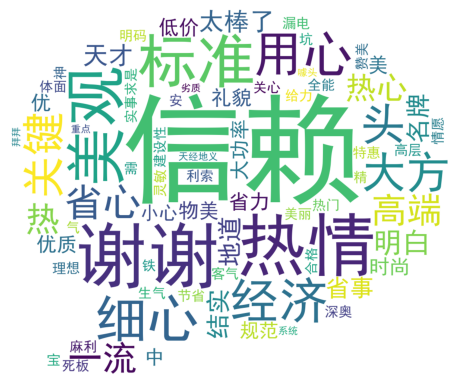

In [32]:
# 绘制词云
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 正面情感词词云
freq_pos = posdata['word'].value_counts()  # 计算情感词权重
freq_pos = freq_pos.sort_values(ascending=False)  # 排序
backgroud_Image = plt.imread('../data/pl.jpg')  # 设置背景图片路径
wordcloud = WordCloud(font_path='../data/simhei.ttf',  # 设置字体
                      max_words=100,  # 设置最大词数
                      background_color='white',  # 设置背景色
                      mask=backgroud_Image)  # 设置背景图
pos_wordcloud = wordcloud.fit_words(freq_pos)  # 填充词
plt.imshow(pos_wordcloud)  # 显示词云图
plt.axis('off')  # 去除图片坐标轴
plt.show()

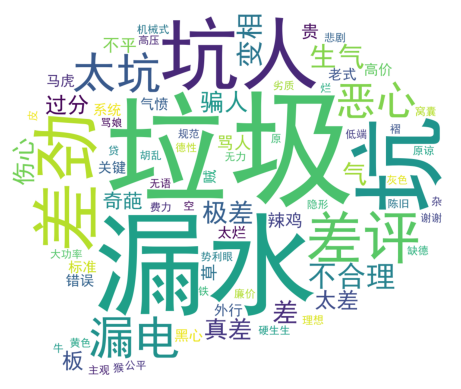

In [33]:
# 负面情感词词云
freq_neg = negdata['word'].value_counts()  # 计算情感词权重
freq_neg = freq_neg.sort_values(ascending=False)  # 排序
neg_wordcloud = wordcloud.fit_words(freq_neg)  # 填充词
plt.imshow(neg_wordcloud)  # 显示词云图
plt.axis('off')  # 去除图片坐标轴
plt.show()

In [34]:
# 将结果写出,每条评论作为一行
posdata.to_csv("../tmp/posdata.csv", index = False, encoding = 'utf-8')
negdata.to_csv("../tmp/negdata.csv", index = False, encoding = 'utf-8')

In [35]:
# 建立词典及语料库

import pandas as pd
import numpy as np
import re
import itertools
import matplotlib.pyplot as plt

# 载入情感分析后的数据
posdata = pd.read_csv("../data/posdata.csv", encoding = 'utf-8')
negdata = pd.read_csv("../data/negdata.csv", encoding = 'utf-8')

In [36]:
from gensim import corpora, models
# 建立词典
pos_dict = corpora.Dictionary([[word] for word in posdata['word']])  # 正面
neg_dict = corpora.Dictionary([[word] for word in negdata['word']])  # 负面
print(pos_dict)
print(neg_dict)

Dictionary<1672 unique tokens: ['东西', '收到', '这么久', '忘', '好评']...>
Dictionary<2139 unique tokens: ['前', '天下', '单买', '用上', '发现']...>


In [37]:
# 建立语料库
# 首先创建文档列表（按评论分组）
pos_documents = posdata.groupby('index_content')['word'].apply(list).tolist()
neg_documents = negdata.groupby('index_content')['word'].apply(list).tolist()

pos_corpus = [pos_dict.doc2bow(doc) for doc in pos_documents]  # 正面
neg_corpus = [neg_dict.doc2bow(doc) for doc in neg_documents]  # 负面
print(pos_corpus)
print(neg_corpus)

[[(0, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 2), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1)], [(12, 1), (13, 1), (14, 1), (15, 1)], [(1, 1), (6, 2), (7, 1), (12, 1), (16, 3), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1)], [(12, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1)], [(10, 1), (19, 1), (33, 1), (38, 2), (51, 1), (52, 1), (53, 1)], [(5, 1), (10, 1), (12, 3), (27, 1), (54, 2), (55, 1), (56, 1), (57, 2), (58, 1), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1), (69, 1), (70, 1)], [(12, 2), (13, 1), (32, 1), (33, 1), (71, 2), (72, 1), (73, 1), (74, 2), (75, 1), (76, 1), (77, 1), (78, 1), (79, 1), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 1), (86, 1), (87, 1), (88, 1)], [(12, 1), (32, 1), (37, 1), (89, 1), (90, 1),

In [38]:
# 构造主题数寻优函数
def cos(vector1, vector2):  # 余弦相似度函数
    dot_product = 0.0;  
    normA = 0.0;  
    normB = 0.0;  
    for a,b in zip(vector1, vector2): 
        dot_product += a*b  
        normA += a**2  
        normB += b**2  
    if normA == 0.0 or normB==0.0:  
        return(None)  
    else:  
        return(dot_product / ((normA**0.5) * (normB**0.5)))   #返回余弦相似度

In [39]:
# 主题数寻优
def lda_k(x_corpus, x_dict):  
    
    # 初始化平均余弦相似度
    mean_similarity = []
    mean_similarity.append(1)
    
    # 循环生成主题并计算主题间相似度
    for i in np.arange(2, 11):
        lda = models.LdaModel(x_corpus, num_topics=i, id2word=x_dict)  # LDA模型训练
        
        # 提取各主题词
        top_word = []
        for k in np.arange(i):
            # 直接提取词语，不需要正则表达式
            topic_words = lda.show_topic(k, topn=20)
            words = [word for word, prob in topic_words]  # 直接提取词语
            top_word.append(words)
           
        # 构造词频向量
        word = sum(top_word, [])  # 列出所有的词   
        unique_word = set(word)  # 去除重复的词
        unique_word = list(unique_word)  # 转换为列表保持顺序
        
        # 构造主题词列表，行表示主题号，列表示各主题词
        mat = []
        for j in np.arange(i):
            top_w = top_word[j]
            mat.append(np.array([1 if w in top_w else 0 for w in unique_word]))  
            
        p = list(itertools.combinations(range(i), 2))
        l = len(p)
        top_similarity = []
        for w in np.arange(l):
            vector1 = mat[p[w][0]]
            vector2 = mat[p[w][1]]
            similarity = cos(vector1, vector2)
            if similarity is not None:
                top_similarity.append(similarity)
            
        # 计算平均余弦相似度
        if top_similarity:
            mean_similarity.append(sum(top_similarity)/len(top_similarity))
        else:
            mean_similarity.append(0)
    return(mean_similarity)

In [40]:
# 计算主题平均余弦相似度
pos_k = lda_k(pos_corpus, pos_dict)  
neg_k = lda_k(neg_corpus, neg_dict)     
print(pos_k)
print(neg_k)

[1, 0.7999999999999998, 0.6999999999999998, 0.5999999999999998, 0.6249999999999998, 0.5533333333333332, 0.5976190476190476, 0.5464285714285715, 0.5305555555555554, 0.5044444444444445]
[1, 0.6499999999999999, 0.5666666666666665, 0.5249999999999999, 0.49499999999999994, 0.4566666666666665, 0.42142857142857126, 0.4089285714285715, 0.4333333333333333, 0.3877777777777778]


Text(0.5, 1.0, '（120毛迪迅）LDA主题数寻优 - 负面评论')

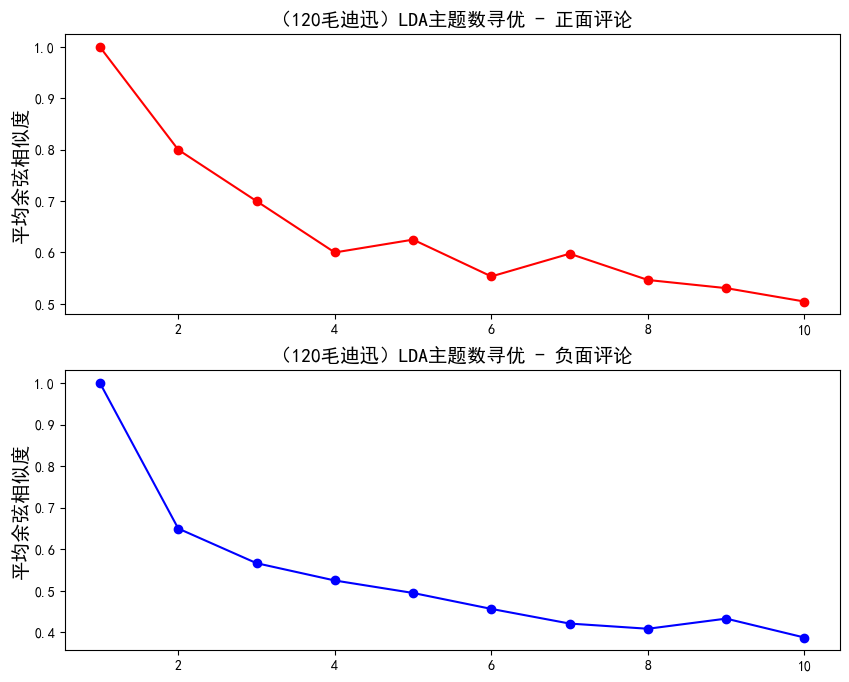

In [41]:
# 绘制主题平均余弦相似度图形
from matplotlib.font_manager import FontProperties  
font = FontProperties(size=14)
#解决中文及负号显示问题
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus'] = False  
fig = plt.figure(figsize=(10,8))
ax1 = fig.add_subplot(211)
ax1.plot(range(1, len(pos_k)+1), pos_k, 'ro-')
ax1.set_ylabel('平均余弦相似度', fontproperties=font)
ax1.set_title('（120毛迪迅）LDA主题数寻优 - 正面评论', fontproperties=font, size=14)

ax2 = fig.add_subplot(212)
ax2.plot(range(1, len(neg_k)+1), neg_k, 'bo-')
ax2.set_ylabel('平均余弦相似度', fontproperties=font)
ax2.set_title('（120毛迪迅）LDA主题数寻优 - 负面评论', fontproperties=font, size=14)

In [42]:
# LDA主题分析
pos_lda = models.LdaModel(pos_corpus, num_topics=3, id2word=pos_dict, random_state=42)
neg_lda = models.LdaModel(neg_corpus, num_topics=3, id2word=neg_dict, random_state=42)
pos_lda.print_topics(num_words=10)

[(0,
  '0.057*"安装" + 0.022*"师傅" + 0.020*"满意" + 0.020*"值得" + 0.017*"信赖" + 0.016*"品牌" + 0.012*"不错" + 0.011*"送货" + 0.010*"好评" + 0.009*"很快"'),
 (1,
  '0.056*"安装" + 0.033*"师傅" + 0.027*"不错" + 0.025*"很快" + 0.015*"满意" + 0.012*"服务" + 0.011*"送货" + 0.011*"快递" + 0.009*"赞" + 0.009*"好评"'),
 (2,
  '0.039*"安装" + 0.024*"满意" + 0.016*"师傅" + 0.015*"速度" + 0.015*"服务" + 0.013*"不错" + 0.012*"质量" + 0.012*"送货" + 0.012*"信赖" + 0.012*"值得"')]

In [43]:
neg_lda.print_topics(num_words = 10)

[(0,
  '0.059*"安装" + 0.020*"师傅" + 0.012*"太" + 0.009*"高" + 0.009*"装" + 0.008*"安装费" + 0.008*"售后" + 0.008*"客服" + 0.008*"东西" + 0.006*"贵"'),
 (1,
  '0.046*"安装" + 0.016*"差" + 0.012*"售后" + 0.011*"师傅" + 0.009*"太" + 0.009*"收费" + 0.008*"评" + 0.008*"收" + 0.007*"坑" + 0.006*"太慢"'),
 (2,
  '0.033*"安装" + 0.012*"加热" + 0.011*"垃圾" + 0.010*"售后" + 0.010*"慢" + 0.009*"不好" + 0.009*"差" + 0.009*"客服" + 0.008*"太" + 0.008*"安装费"')]

In [44]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


def prepare_data(posdata, negdata):
    """准备AHP-FCE模型所需数据"""
    # 按评论ID分组，合并词语
    pos_docs = posdata.groupby('index_content')['word'].apply(lambda x: ' '.join(x)).reset_index()
    neg_docs = negdata.groupby('index_content')['word'].apply(lambda x: ' '.join(x)).reset_index()
    
    # 添加标签
    pos_docs['label'] = 1  # 正面
    neg_docs['label'] = 0  # 负面
    
    # 合并数据
    all_data = pd.concat([pos_docs, neg_docs], ignore_index=True)
    
    return all_data

# 准备数据
data = prepare_data(posdata, negdata)

# 特征提取 - TF-IDF
vectorizer = TfidfVectorizer(max_features=1000, stop_words=['的', '了', '是', '在', '有'])
X = vectorizer.fit_transform(data['word'])
y = data['label'].values

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [45]:
class AHP_FCEModel:
    """AHP-模糊综合评价模型"""
    
    def __init__(self, feature_names):
        self.feature_names = feature_names
        self.weights = None
        self.membership_functions = None
        
    def ahp_weight_calculation(self, comparison_matrix):
        """AHP层次分析法计算权重"""
        # 计算特征值特征向量
        eigenvalues, eigenvectors = np.linalg.eig(comparison_matrix)
        max_index = np.argmax(eigenvalues.real)
        weight_vector = eigenvectors[:, max_index].real
        
        # 归一化权重
        self.weights = weight_vector / np.sum(weight_vector)
        return self.weights
    
    def create_membership_functions(self, X_train, y_train):
        """创建模糊隶属度函数"""
        n_features = X_train.shape[1]
        n_classes = len(np.unique(y_train))
        
        self.membership_functions = {}
        
        for feature_idx in range(min(10, n_features)):  # 取前10个重要特征
            feature_values = X_train[:, feature_idx].toarray().flatten()
            
            # 按类别分离数据
            pos_values = feature_values[y_train == 1]
            neg_values = feature_values[y_train == 0]
            
            # 计算每个类别的统计量
            self.membership_functions[feature_idx] = {
                'positive': {
                    'mean': np.mean(pos_values) if len(pos_values) > 0 else 0,
                    'std': np.std(pos_values) if len(pos_values) > 0 else 1
                },
                'negative': {
                    'mean': np.mean(neg_values) if len(neg_values) > 0 else 0,
                    'std': np.std(neg_values) if len(neg_values) > 0 else 1
                }
            }
    
    def gaussian_membership(self, x, mean, std):
        """高斯隶属度函数"""
        if std == 0:
            return 1.0 if x == mean else 0.0
        return np.exp(-((x - mean) ** 2) / (2 * std ** 2))
    
    def predict_single(self, x):
        """单样本预测"""
        if self.weights is None or self.membership_functions is None:
            raise ValueError("模型尚未训练")
        
        positive_score = 0
        negative_score = 0
        
        for feature_idx in self.membership_functions.keys():
            if feature_idx < len(self.weights):
                feature_value = x[feature_idx]
                mf = self.membership_functions[feature_idx]
                
                # 计算正负面隶属度
                pos_membership = self.gaussian_membership(
                    feature_value, mf['positive']['mean'], mf['positive']['std'])
                neg_membership = self.gaussian_membership(
                    feature_value, mf['negative']['mean'], mf['negative']['std'])
                
                # 加权得分
                positive_score += self.weights[feature_idx] * pos_membership
                negative_score += self.weights[feature_idx] * neg_membership
        
        # 模糊综合评价
        if positive_score > negative_score:
            return 1
        else:
            return 0
    
    def predict(self, X):
        """批量预测"""
        predictions = []
        X_dense = X.toarray()
        
        for i in range(X_dense.shape[0]):
            pred = self.predict_single(X_dense[i])
            predictions.append(pred)
        
        return np.array(predictions)
    
    def fit(self, X_train, y_train):
        """训练模型"""
        # 简化AHP：使用TF-IDF特征重要性作为权重
        feature_importance = np.array(X_train.mean(axis=0)).flatten()
        self.weights = feature_importance / np.sum(feature_importance)
        
        # 创建隶属度函数
        self.create_membership_functions(X_train, y_train)
        
        return self

In [46]:
# 训练AHP-FCE模型

ahp_fce_model = AHP_FCEModel(feature_names=vectorizer.get_feature_names_out())
ahp_fce_model.fit(X_train, y_train)

print("AHP-FCE模型训练完成")

# 预测
y_pred_ahp = ahp_fce_model.predict(X_test)

# 评估
accuracy_ahp = accuracy_score(y_test, y_pred_ahp)
print(f"AHP-FCE模型准确率: {accuracy_ahp:.4f}")
print("\nAHP-FCE模型详细评估:")
print(classification_report(y_test, y_pred_ahp, target_names=['负面', '正面']))

AHP-FCE模型训练完成
AHP-FCE模型准确率: 0.5535

AHP-FCE模型详细评估:
              precision    recall  f1-score   support

          负面       0.00      0.00      0.00       121
          正面       0.55      1.00      0.71       150

    accuracy                           0.55       271
   macro avg       0.28      0.50      0.36       271
weighted avg       0.31      0.55      0.39       271



D:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Software\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
